# 02 — Forward local-volatility PDE pricer

In the first notebook, we checked the basic Black–Scholes and grid functions.

In this notebook, we build the forward pricing map

$$
\sigma_{\mathrm{loc}}(K,T)
\longrightarrow
C(K,T).
$$

For the first validation, local volatility is constant. In that case, the PDE
prices should be close to Black–Scholes prices.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.pricing.black_scholes import black_scholes_call
from src.pricing.local_vol_pde import (
    interpolate_call_prices,
    solve_forward_dupire,
)


## 1. The equation we solve

The forward Dupire PDE is

$$
\frac{\partial C}{\partial T}
=
\frac{1}{2}\sigma_{\mathrm{loc}}(K,T)^2K^2
\frac{\partial^2 C}{\partial K^2}
-
(r-q)K\frac{\partial C}{\partial K}
-
qC.
$$

The initial condition is the option payoff:

$$
C(K,0)=\max(S_0-K,0).
$$

We begin with a constant local volatility of \(20\%\).


In [3]:
spot = 100.0
rate = 0.05
dividend_yield = 0.0
constant_local_volatility = 0.20

strike_grid, time_grid, call_surface = solve_forward_dupire(
    spot=spot,
    local_volatility=constant_local_volatility,
    max_maturity=1.0,
    rate=rate,
    dividend_yield=dividend_yield,
    strike_max=300.0,
    number_of_strike_points=301,
    number_of_time_steps=300,
)

print("Strike-grid shape:", strike_grid.shape)
print("Time-grid shape:", time_grid.shape)
print("Call-surface shape:", call_surface.shape)


Strike-grid shape: (301,)
Time-grid shape: (301,)
Call-surface shape: (301, 301)


## 2. Check the initial payoff

The first row of the PDE surface corresponds to \(T=0\). It must equal

$$
\max(S_0-K,0).
$$


Maximum initial-condition error: 0.000e+00


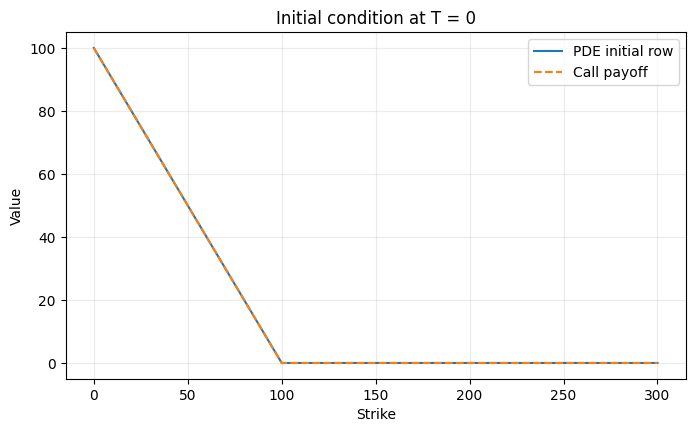

In [4]:
initial_payoff = np.maximum(spot - strike_grid, 0.0)
maximum_initial_error = np.max(
    np.abs(call_surface[0] - initial_payoff)
)

print(f"Maximum initial-condition error: {maximum_initial_error:.3e}")
assert maximum_initial_error < 1e-12

plt.figure(figsize=(8, 4.5))
plt.plot(strike_grid, call_surface[0], label="PDE initial row")
plt.plot(
    strike_grid,
    initial_payoff,
    linestyle="--",
    label="Call payoff",
)
plt.xlabel("Strike")
plt.ylabel("Value")
plt.title("Initial condition at T = 0")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 3. Option prices at selected maturities

As maturity increases, the call-price curve becomes smoother because there is
more time for uncertainty in the underlying price to matter.


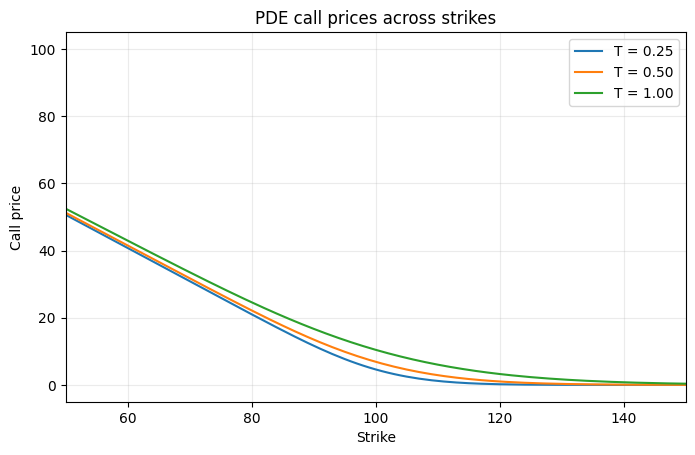

In [5]:
selected_maturities = [0.25, 0.50, 1.00]

plt.figure(figsize=(8, 4.8))

for maturity in selected_maturities:
    row_index = np.argmin(np.abs(time_grid - maturity))
    plt.plot(
        strike_grid,
        call_surface[row_index],
        label=f"T = {time_grid[row_index]:.2f}",
    )

plt.xlim(50, 150)
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("PDE call prices across strikes")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 4. Compare the PDE with Black–Scholes

A constant local-volatility model is just the Black–Scholes model. Therefore,
the two pricing methods should give nearly the same answer.

Any small difference is numerical discretisation error from the finite strike
and time grids.


In [6]:
test_strikes = np.array([80.0, 100.0, 120.0])
test_maturities = np.array([0.25, 0.50, 1.00])

strike_mesh, maturity_mesh = np.meshgrid(
    test_strikes,
    test_maturities,
)

pde_prices = interpolate_call_prices(
    strike_grid=strike_grid,
    time_grid=time_grid,
    call_surface=call_surface,
    strikes=strike_mesh,
    maturities=maturity_mesh,
)

black_scholes_prices = black_scholes_call(
    spot=spot,
    strike=strike_mesh,
    maturity=maturity_mesh,
    rate=rate,
    volatility=constant_local_volatility,
    dividend_yield=dividend_yield,
)

absolute_errors = np.abs(
    pde_prices - black_scholes_prices
)

print("PDE prices:")
print(np.round(pde_prices, 6))

print("\nBlack-Scholes prices:")
print(np.round(black_scholes_prices, 6))

print("\nAbsolute errors:")
print(np.round(absolute_errors, 6))

print(
    "\nMaximum absolute error:",
    f"{np.max(absolute_errors):.6f}",
)

assert np.max(absolute_errors) < 0.01


PDE prices:
[[21.021451  4.610034  0.200008]
 [22.174225  6.885223  1.02204 ]
 [24.587933 10.448115  3.246342]]

Black-Scholes prices:
[[21.021298  4.614997  0.199764]
 [22.174561  6.888729  1.022615]
 [24.588835 10.450584  3.247477]]

Absolute errors:
[[0.000153 0.004963 0.000244]
 [0.000336 0.003506 0.000575]
 [0.000902 0.002468 0.001135]]

Maximum absolute error: 0.004963


## 5. Visual comparison at one year

The two curves should almost overlap.


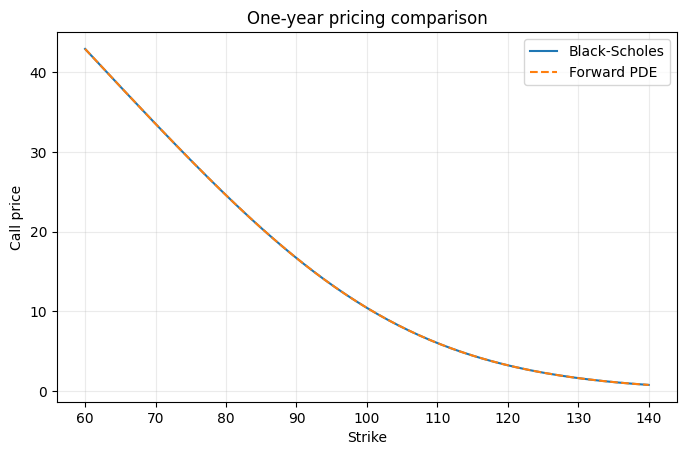

In [7]:
comparison_strikes = np.linspace(60.0, 140.0, 161)

pde_one_year = interpolate_call_prices(
    strike_grid=strike_grid,
    time_grid=time_grid,
    call_surface=call_surface,
    strikes=comparison_strikes,
    maturities=1.0,
)

black_scholes_one_year = black_scholes_call(
    spot=spot,
    strike=comparison_strikes,
    maturity=1.0,
    rate=rate,
    volatility=constant_local_volatility,
    dividend_yield=dividend_yield,
)

plt.figure(figsize=(8, 4.8))
plt.plot(
    comparison_strikes,
    black_scholes_one_year,
    label="Black-Scholes",
)
plt.plot(
    comparison_strikes,
    pde_one_year,
    linestyle="--",
    label="Forward PDE",
)
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("One-year pricing comparison")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. A non-constant local-volatility example

The PDE function also accepts a Python function instead of one constant. This
example is only a demonstration; it is not yet our final synthetic surface.


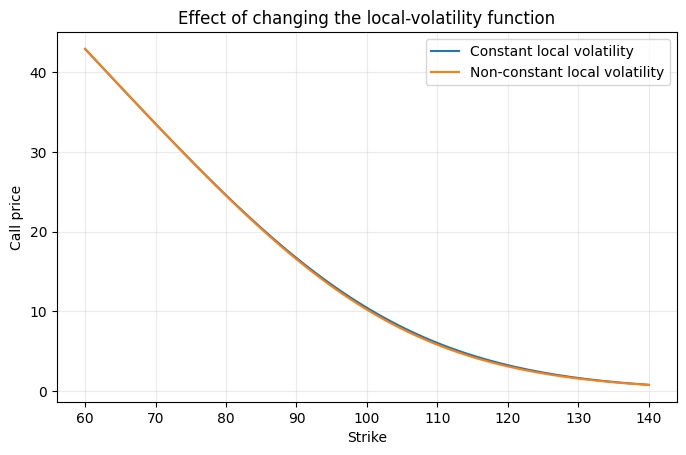

In [8]:
def simple_local_volatility(strikes, maturity):
    # Smooth demonstration surface in strike and maturity.
    relative_strike = strikes / spot - 1.0

    return (
        0.18
        + 0.10 * relative_strike**2
        + 0.03 * np.exp(-2.0 * maturity)
    )


_, _, nonconstant_call_surface = solve_forward_dupire(
    spot=spot,
    local_volatility=simple_local_volatility,
    max_maturity=1.0,
    rate=rate,
    dividend_yield=dividend_yield,
    strike_max=300.0,
    number_of_strike_points=301,
    number_of_time_steps=300,
)

nonconstant_prices = interpolate_call_prices(
    strike_grid=strike_grid,
    time_grid=time_grid,
    call_surface=nonconstant_call_surface,
    strikes=comparison_strikes,
    maturities=1.0,
)

plt.figure(figsize=(8, 4.8))
plt.plot(
    comparison_strikes,
    pde_one_year,
    label="Constant local volatility",
)
plt.plot(
    comparison_strikes,
    nonconstant_prices,
    label="Non-constant local volatility",
)
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("Effect of changing the local-volatility function")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Stage 2 result

We now have the forward pricing engine

$$
\sigma_{\mathrm{loc}}(K,T)
\longrightarrow
C(K,T).
$$

The key validation passed: when local volatility is constant, the PDE prices
are close to Black–Scholes prices.

The next stage will define proper synthetic local-volatility surfaces and use
this PDE solver to generate synthetic option-market data.
